In [142]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.signal import convolve2d



In [143]:
#utility functions
def vec(x_img):
    """
    Input:
        x_img : array of shape (H, W)
    Output:
        x_vec : array of shape (H*W,)
    """
    return x_img.reshape(-1)


def img(x_vec, shape):
    """
    Input:
        x_vec : array of shape (H*W,)
        shape : (H, W)
    Output:
        x_img : array of shape (H, W)
    """
    return x_vec.reshape(shape)


Image shape: (256, 256)


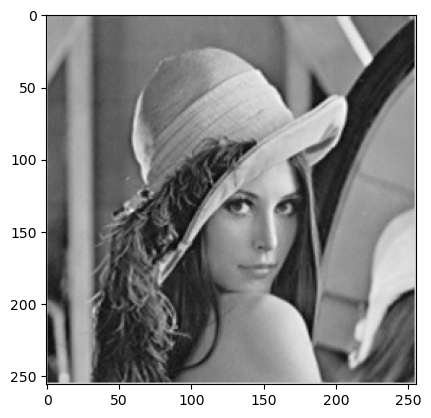

In [144]:
def load_grayscale_image(path, N=256):
    """
    Load image, convert to grayscale, resize/crop to NxN,
    and normalize pixel values to [0, 1].
    """
    img = Image.open(path).convert("L")  # L = grayscale

    # Resize if needed (keeps things simple)
    if img.size != (N, N):
        img = img.resize((N, N), resample=Image.BICUBIC)

    x = np.asarray(img, dtype=np.float64)

    # Normalize to [0, 1]
    x = (x - x.min()) / (x.max() - x.min()) #the image i use is already normalized 

    return x

x_img = load_grayscale_image('woman.png')
plt.imshow(x_img, cmap="gray")
print('Image shape:', x_img.shape)

Shape of blurred image: (256, 256)


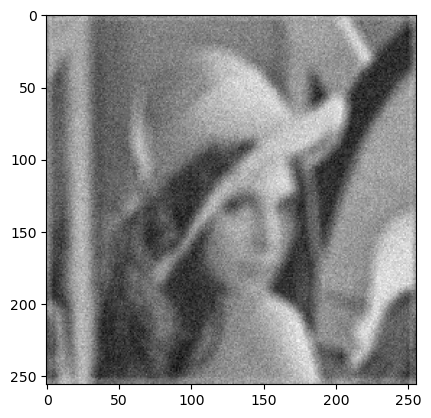

In [145]:
#add blur + gaussian noise to image

def uniform_blur_kernel(k=9):
    """
    Uniform blur kernel of dimension k
    """
    h = np.ones((k, k))
    h /= h.sum()
    return h

def A(x_img, h):
    return convolve2d(x_img, h, mode="same", boundary="wrap")

def AT(x_img, h):
    h_flip = h[::-1, ::-1]
    return convolve2d(x_img, h_flip, mode="same", boundary="wrap")

def add_blur(x_img,h, sigma=0.05):
    return A(x_img,h) + sigma * np.random.randn(*x_img.shape)

h = uniform_blur_kernel()
y_img = add_blur(x_img,h)
plt.imshow(y_img, cmap='gray')
print('Shape of blurred image:', y_img.shape)

In [146]:
#new blurring functions acting on 1D vectors 
H, W = 128, 128
shape = (H, W)

# kept for reference / ad-hoc use
def A_vec(x_vec, h):
    x_img = x_vec.reshape(shape)
    y_img = convolve2d(x_img, h, mode="same", boundary="wrap")
    return y_img.reshape(-1)

def AT_vec(x_vec, h):
    x_img = x_vec.reshape(shape)
    h_flip = h[::-1, ::-1]
    y_img = convolve2d(x_img, h_flip, mode="same", boundary="wrap")
    return y_img.reshape(-1)


def make_fft_operators(h, shape):
    """
    Precompute the FFT of the blur kernel h once.
    Returns (A_fft, AT_fft) — FFT-based equivalents of A_vec/AT_vec
    with wrap (circular) boundary, much faster than spatial convolve2d.
    """
    H, W = shape
    kh, kw = h.shape

    # Pad kernel to image size and shift its center to (0,0)
    # so that FFT multiplication gives the same result as convolve2d(..., boundary="wrap")
    h_padded = np.zeros((H, W), dtype=np.float64)
    h_padded[:kh, :kw] = h
    h_padded = np.roll(h_padded, shift=(-kh // 2, -kw // 2), axis=(0, 1))

    H_fft = np.fft.rfft2(h_padded)        # precomputed once
    H_fft_conj = np.conj(H_fft)           # transpose = conjugate in Fourier domain

    def A_fft(x_vec):
        x_img = x_vec.reshape(shape)
        y_img = np.fft.irfft2(H_fft * np.fft.rfft2(x_img), s=(H, W))
        return y_img.reshape(-1)

    def AT_fft(x_vec):
        x_img = x_vec.reshape(shape)
        y_img = np.fft.irfft2(H_fft_conj * np.fft.rfft2(x_img), s=(H, W))
        return y_img.reshape(-1)

    return A_fft, AT_fft


def grad_gmrf_vec(x_vec):
    x_img = x_vec.reshape(shape)

    g_img = (
        4 * x_img
        - np.roll(x_img,  1, axis=0)
        - np.roll(x_img, -1, axis=0)
        - np.roll(x_img,  1, axis=1)
        - np.roll(x_img, -1, axis=1)
    )

    return g_img.reshape(-1)


def make_gradU(y_vec, h):
    A_fft, AT_fft = make_fft_operators(h, shape)  # FFT of h computed once here

    def gradU(x_vec):
        data_grad = AT_fft(A_fft(x_vec) - y_vec) / sigma**2
        prior_grad = grad_gmrf_vec(x_vec) / sigma_x**2

        g = data_grad + prior_grad

        if not np.all(np.isfinite(g)):
            print("Gradient exploded")

        return g

    return gradU


In [ ]:
from langevin_samplers import (
    run_hmc,
    run_k_langevin,
    run_od_langevin, 
    sample_run_streaming_mean
)

sigma = 0.0024
sigma_x = 0.05

h = uniform_blur_kernel()
x_img = load_grayscale_image('woman.png', N=128)
y_img = add_blur(x_img,h, sigma=sigma)
y_vec = vec(y_img)

x0_vec = vec(y_img.copy())              # (65536,)
v0_vec = np.random.randn(x0_vec.size)

gradU = make_gradU(y_vec,h)

x_mean_vec = sample_run_streaming_mean(
    x0_vec,
    v0_vec,
    gradU,
    N=1000000,
    delta=1e-3,
    K=1,
    eta=0,
    T=1,
    burn=1000,
    thin=10
)


: 

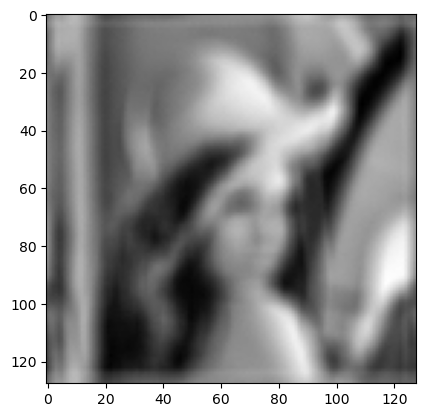

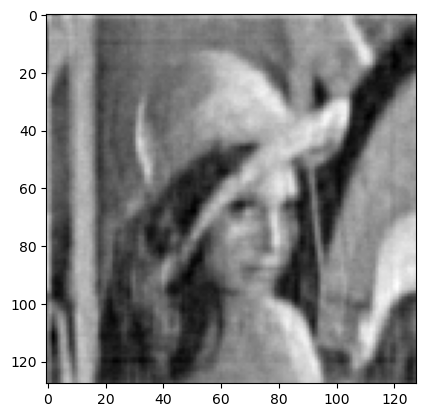

In [166]:
x_mean_img = img(x_mean_vec, (128,128))
plt.figure()
plt.imshow(y_img, cmap='gray')
plt.figure()
plt.imshow(x_mean_img, cmap='gray')